# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

from matplotlib.gridspec import GridSpec
import h5py

import sys
sys.path.append("../utils")
from utils import *

In [3]:
update_rc_params('talk')

## Theory DOS

In [4]:
def plot_theory_dos(fig, ax, norm, cmap):
    with h5py.File('../data/ed-fig-large-nD-map/data_DOS.h5', 'r') as f:
        # Print all keys
        print(list(f.keys()))
        Ds = f['uD_meV'][:]
        ns = f['ns_per_A12'][:] * 4 # spin valley deg
        rhos_per_Auc = f['rhos_single_particle_per_eV_per_A12'][:]
        pernm2_convertor = 19.081
        
        plot = plt.pcolormesh(ns, Ds, rhos_per_Auc*pernm2_convertor, cmap=cmap, norm=norm, rasterized=True, lw=0)
        plot = plt.pcolormesh(ns, -Ds, rhos_per_Auc*pernm2_convertor, cmap=cmap, norm=norm, rasterized=True, lw=0)
        ax = plt.gca()
        ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
        ax.set_ylabel(r'$u_D$ (meV)')
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    return plot

['ns_per_A12', 'rhos_single_particle_per_eV_per_A12', 'rhparams', 'uD_meV']


['/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-large-nD-map-dos.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-large-nD-map-dos.png']

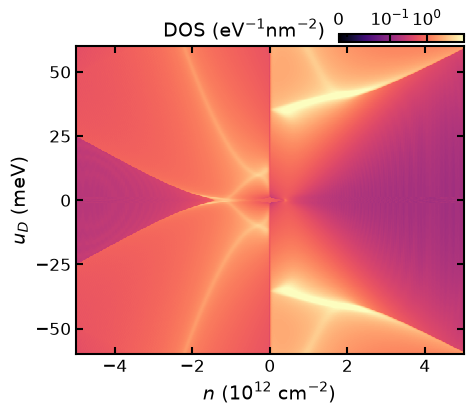

In [5]:
fig = plt.figure(figsize=(5,4))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=0.05, vmin=0, vmax=10)
plot = plot_theory_dos(fig, ax, norm, cmap="magma")

pos = ax.get_position()
cb_width = 0.25 
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0,1e-1, 1], \
                  orientation='horizontal')
cb.ax.annotate(r'DOS (eV$^{-1}\mathrm{nm}^{-2}$)', xy=(-0.10, 1.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

ax.set_xlim(-5, 5)
ax.set_ylim(-60, 60)
#ax.set_ylim(30, 60)
save_fig(fig, "ed-fig-large-nD-map-dos")

## Large nD map with hole side

/tmp/ipykernel_770105/1721924831.py:28: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I
/tmp/ipykernel_770105/1721924831.py:28: RuntimeWarning: invalid value encountered in divide
  zs = Vxx / I


['/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-large-nD-map-rxx.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/ed-fig-large-nD-map-rxx.png']

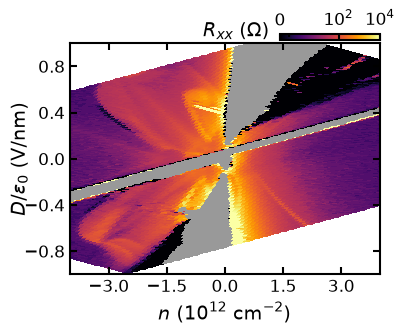

In [6]:
def plot_gatemap(fig, ax, norm, cmap="viridis", files=[1261], contact_id=5):
    contact_pairs = {
    'curr': {'indices': [4], 'norm': colors.Normalize(vmin=0, vmax=1), 'cmap': 'viridis', 'label': r'$I/I_0$'},
    'long1': {'indices': [contact_id], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    for file in files:
        for pair, options in contact_pairs.items():
            indices = options['indices']
            norm = options.get('norm', None)
            cmap = options['cmap']
            label = options['label']
            vmin = options.get('vmin', None)
            vmax = options.get('vmax', None)
            for ind in indices:
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                xs = data['xs'] # top gate
                ys = data['ys'] # back gate
                phase = data[f'sr830_{ind}_P']
        
                if pair=='curr':
                    I = data['sr830_4_X']
                    zs= I/np.nanmax(I)
                else:
                    I = data['sr830_4_X']
                    Vxx = data[f'sr830_{ind}_X']
                    zs = Vxx / I
                    
                Vbg = np.matlib.repmat(ys, len(xs), 1).T
                Vtg = np.matlib.repmat(xs, len(ys), 1)
        
                finite = np.isfinite(I)
                mask = np.abs(I) < 0.7 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
            
                xs, ys = calculate_n_D(Vbg, Vtg, dtg=16, dbg=25.5)
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap, rasterized=True, lw=0)
                
                zs_m = np.ma.array(np.ones(zs.shape), mask=~mask  | ~finite)
                gray_cmap = colors.ListedColormap(["0.6"])
                ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)
        
                ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)', labelpad=-4)
                ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
                ax.xaxis.set_major_locator(plt.MaxNLocator(6))
                ax.yaxis.set_major_locator(plt.MaxNLocator(5))
        return plot


fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=50, vmin=0, vmax=1E3)
plot = plot_gatemap(fig, ax, norm, "inferno", contact_id=5)

pos = ax.get_position()
cb_width = 0.25  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e3], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 1.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

ax.set_xlim(-4,4)
ax.set_ylim(-1,1)

save_fig(fig, "ed-fig-large-nD-map-rxx")

# Full figure

['ns_per_A12', 'rhos_single_particle_per_eV_per_A12', 'rhparams', 'uD_meV']


/tmp/ipykernel_770105/1721924831.py:28: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I
/tmp/ipykernel_770105/1721924831.py:28: RuntimeWarning: invalid value encountered in divide
  zs = Vxx / I


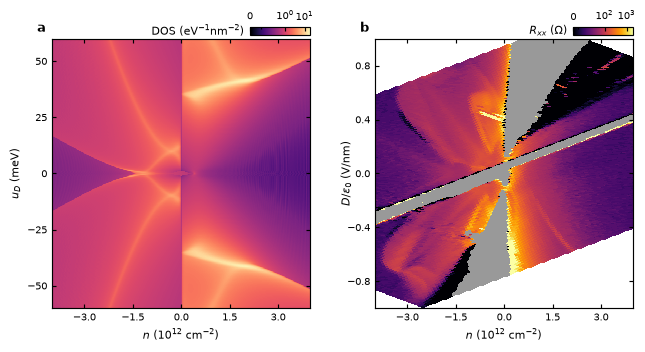

In [7]:
update_rc_params('paper')  # paper style for this final figure

# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 3.5))
gs = GridSpec(1, 2, figure=fig,   
                       width_ratios=[1, 1],
                       height_ratios=[1],
                       hspace=0.4, wspace=0.25)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')

norm = colors.SymLogNorm(linthresh=0.2, vmin=0, vmax=20)
plot = plot_theory_dos(fig, ax, norm, cmap="magma")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 1, 10], orientation='horizontal')
cb.ax.annotate(r'DOS (eV$^{-1}\mathrm{nm}^{-2}$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  
ax.set_xlim(-4, 4)
ax.set_ylim(-60, 60)

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

norm = colors.SymLogNorm(linthresh=50, vmin=0, vmax=2E3)
plot = plot_gatemap(fig, ax, norm, "inferno", contact_id=5)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e3], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^3$'])
cb.ax.annotate(r'$R_{xx}$ $(\Omega)$', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  
ax.set_xlim(-4, 4)
ax.set_ylim(-1, 1)

plt.show()
fig.savefig("si-fig-large-nD-map.pdf", dpi=300, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default